In [6]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import hvplot.xarray


In [ ]:
FG_AWS = xr.load_dataset('aws_season_1.nc')  # created with code/aws/season_1.ipynb
FG_AWS

<xarray.Dataset> Size: 150kB
Dimensions:           (time: 335)
Coordinates:
    index             (time) int64 3kB 0 1 2 3 4 5 6 ... 329 330 331 332 333 334
  * time              (time) datetime64[ns] 3kB 2024-12-02T10:59:59.971000 .....
Data variables: (12/54)
    RECORD            (time) float64 3kB 6.0 7.0 8.0 9.0 ... 338.0 339.0 340.0
    TempVue20T_C_Avg  (time) float64 3kB -5.659 -6.46 -7.209 ... -4.144 -4.044
    TempVue20T_C_Max  (time) float64 3kB -5.26 -5.13 -6.92 ... -3.49 -3.79 -3.8
    TempVue20T_C_Min  (time) float64 3kB -5.99 -7.25 -7.39 ... -4.14 -4.49 -4.39
    AirTmpC_Avg       (time) float64 3kB -6.217 -6.929 -7.238 ... -4.166 -4.072
    AirTmpC_Max       (time) float64 3kB -6.031 -6.269 -7.1 ... -3.908 -3.866
    ...                ...
    GKN_9m_TmpC       (time) float64 3kB 7.915 9.23 9.59 ... -127.9 -127.9
    GKN_9_2m_TmpC     (time) float64 3kB 9.8 17.45 18.2 ... -127.9 -127.9 -127.9
    GKN_9_4m_TmpC     (time) float64 3kB 8.75 12.52 12.41 ... -127.9 -127.8
    GKN_9_6m_TmpC     (time) float64 3kB 8.53 13.71 14.9 ... -127.9 -127.9
    GKN_9_8m_TmpC     (time) float64 3kB 6.998 14.52 14.79 ... -127.9 -127.8
    GKN_10m_TmpC      (time) float64 3kB 6.675 12.85 12.91 ... -127.9 -127.8

In [531]:
fname = "../../data/flask/aws/AWS18/IMAU_ANT_AWS18.tab"

with open(fname) as f:
    lines = f.readlines()
# Find the first line that contains */
cut_line = next(i for i, line in enumerate(lines) if "*/" in line)
aws18_df = pd.read_csv("../../data/flask/aws/AWS18/IMAU_ANT_AWS18.tab", skiprows=cut_line+1, delimiter='\t', parse_dates=["Date/Time"] )  
aws20_ds1 = aws18_df.set_index("Date/Time").to_xarray()['TTT [°C]']
aws20_ds1

<xarray.DataArray 'TTT [°C]' (Date/Time: 70269)> Size: 562kB
array([-5.8642, -6.204 , -6.308 , ...,  1.1366,  3.2536,  1.3908],
      shape=(70269,))
Coordinates:
  * Date/Time  (Date/Time) datetime64[ns] 562kB 2014-11-25T18:00:00 ... 2022-...

<Axes: >

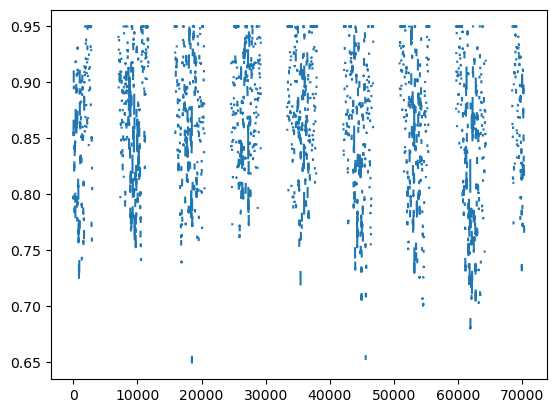

In [549]:
aws18_df['Alb frac'].plot()

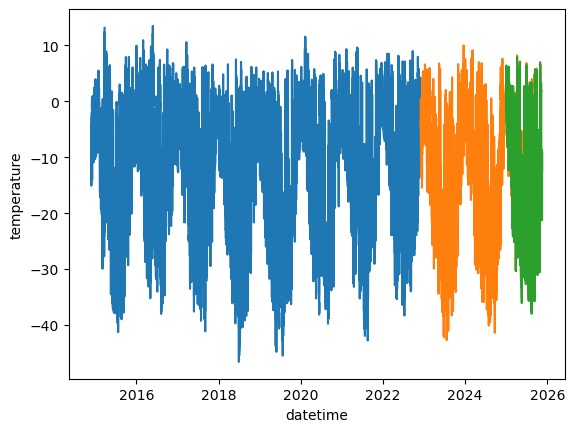

In [ ]:
# load csvs into pandas dataframes
aws20_df1 = pd.read_csv("../../data/flask/aws/AWS20/AWS20_temp.csv", parse_dates=["datetime"] )  
aws20_df2 = pd.read_csv("../../data/flask/aws/AWS20/AWS20_temp_2025.csv", parse_dates=["datetime"] ) 

# rename temperature columns
aws18_df = aws18_df.rename(columns={"TTT [°C]": "temperature"})
aws20_df1 = aws20_df1.rename(columns={"t": "temperature"})
aws20_df2 = aws20_df2.rename(columns={"Thut": "temperature"})

# rename datetime columns
aws18_df = aws18_df.rename(columns={"Date/Time": "datetime"})

# extract temperature data and convert to xarray datasets
def extract_temperature_ds(df): return df.set_index("datetime").to_xarray().temperature
aws18_ds = extract_temperature_ds(aws18_df)
aws20_ds1 = extract_temperature_ds(aws20_df1)
aws20_ds2 = extract_temperature_ds(aws20_df2)


aws20_ds2 = aws20_ds2.where(aws20_ds2 < 20)
aws18_ds.plot()
aws20_ds1.plot()
aws20_ds2.plot()

In [543]:
def add_times(date, y_pos, label, ax):
    ax.axvline(pd.Timestamp(date), color="k", linestyle="--")
    ax.text(pd.Timestamp(date)+pd.Timedelta(days=0.5), y_pos,label, ha="left", va="bottom", fontsize=8)

In [1]:
fig, ax = plt.subplots(1, figsize=(20, 8))
aws18_ds.plot(ax=ax, label='AWS18')
aws20_ds1.plot(ax=ax, label='AWS20 2020-2024')
aws20_ds2.plot(ax=ax, label='AWS20 2025')
ax.set_xlim(pd.Timestamp('2024-11-01'), pd.Timestamp('2025-11-30'))
ax.set_title('AWS Temperature Time Series')
ax.set_ylabel('Temperature (°C)')
add_times('2025-10-30', -42, 'SSA, coud not land', ax)
add_times('2024-11-25', -40, 'Field guides reach FG', ax)
add_times('2024-11-30', -34, 'Science team reach FG', ax)
add_times('2024-12-16', -28, 'End of fieldwork', ax)
ax.grid()
ax.legend()

NameError: name 'plt' is not defined

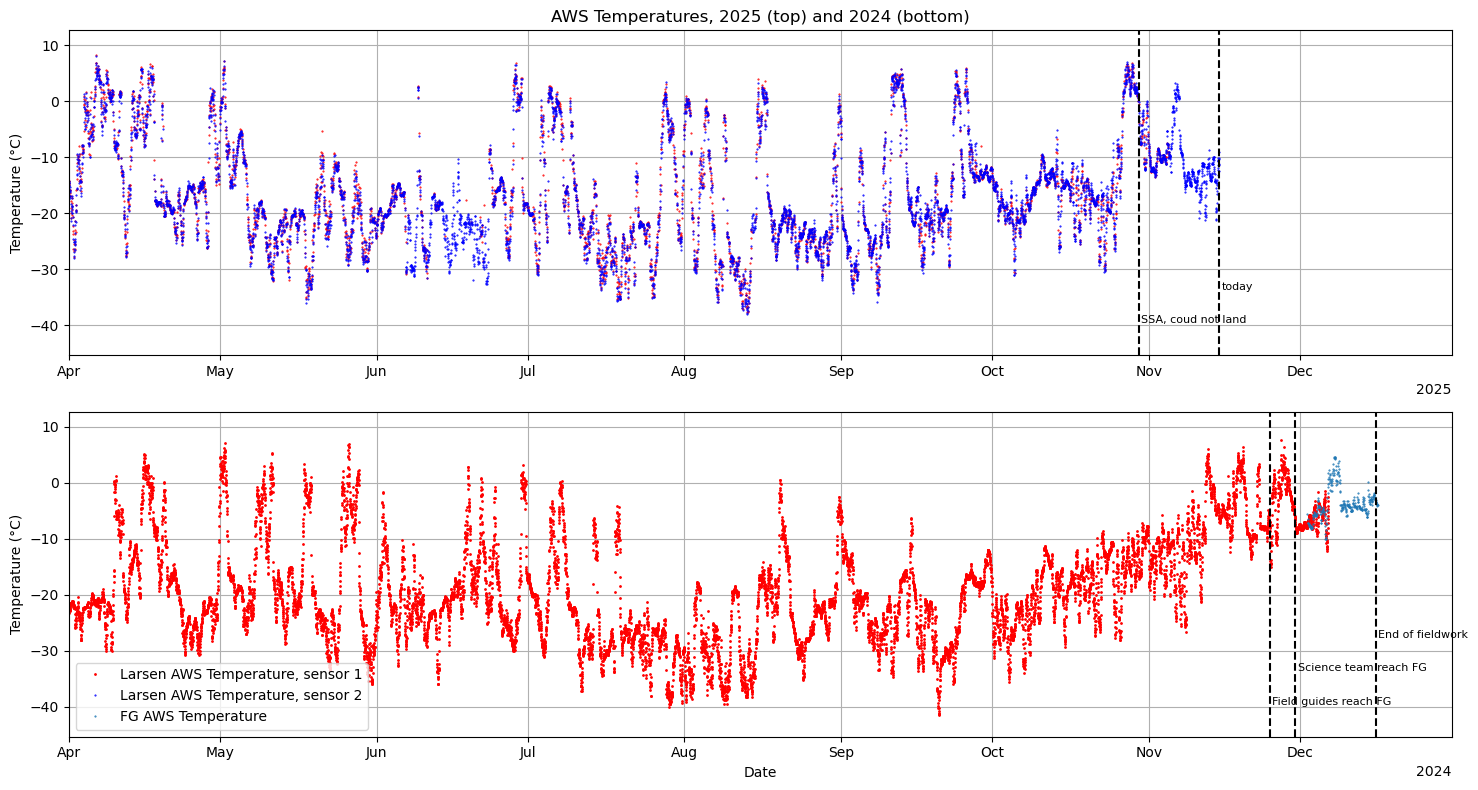

In [489]:
fig, ax = plt.subplots(2, figsize=(15, 8))

def add_times(date, y_pos, label, ax):
    ax.axvline(pd.Timestamp(date), color="k", linestyle="--")
    ax.text(pd.Timestamp(date)+pd.Timedelta(days=0.5), y_pos,label, ha="left", va="bottom", fontsize=8)

year = 2025
aws20_ds1.plot(ax = ax[0], xlim = (pd.Timestamp(f'{year}-4-01'), pd.Timestamp(f'{year}-12-31')), linestyle=' ', marker='.', c = 'r', markersize = 1, label='Larsen AWS Temperature, sensor 1')
aws20_ds2.plot(ax = ax[0], xlim = (pd.Timestamp(f'{year}-4-01'), pd.Timestamp(f'{year}-12-31')),  linestyle=' ', marker='.', c = 'b', markersize = 1, label='Larsen AWS Temperature, sensor 2')
ax[0].set_ylabel('Temperature (°C)')
ax[0].set_xlabel('')
ax[0].set_title(f'AWS Temperatures, 2025 (top) and 2024 (bottom)')
ax[0].grid()
add_times('2025-11-15', -34, 'today', ax[0])
add_times('2025-10-30', -40, 'SSA, coud not land', ax[0])

year = 2024
aws20_ds1.plot(ax = ax[1], xlim = (pd.Timestamp(f'{year}-4-01'), pd.Timestamp(f'{year}-12-31')),  linestyle=' ', marker='o', c = 'r', markersize = 1, label='Larsen AWS Temperature, sensor 1')
aws20_ds2.plot(ax = ax[1], xlim = (pd.Timestamp(f'{year}-4-01'), pd.Timestamp(f'{year}-12-31')),  linestyle=' ', marker='.', c = 'b', markersize = 1, label='Larsen AWS Temperature, sensor 2')
FG_AWS.TempVue20T_C_Avg.plot(ax = ax[1], linestyle=' ', marker='.',label ='FG AWS Temperature', markersize = 1)

ax[1].set_ylabel('Temperature (°C)')
ax[1].set_xlabel('Date')
# ax[1].set_title(f'AWS Temperature records, {year}')
ax[1].grid()



add_times('2024-11-25', -40, 'Field guides reach FG', ax[1])
add_times('2024-11-30', -34, 'Science team reach FG', ax[1])
add_times('2024-12-16', -28, 'End of fieldwork', ax[1]  )
plt.tight_layout()
plt.legend(loc='lower left')

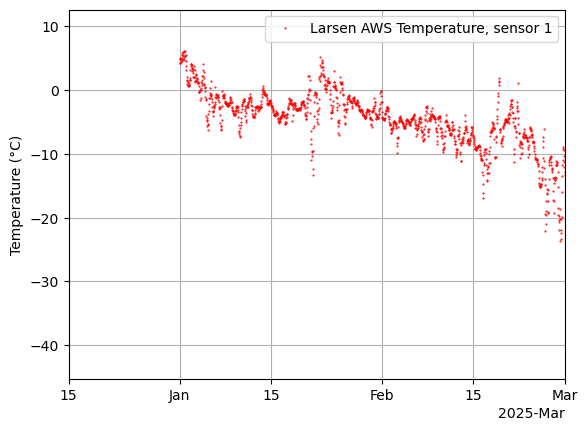

In [603]:
aws20_ds1.plot(xlim = (pd.Timestamp(f'2024-12-15'), pd.Timestamp(f'2025-3-01')), linestyle=' ', marker='.', c = 'r', markersize = 1, label='Larsen AWS Temperature, sensor 1')
plt.ylabel('Temperature (°C)')
plt.xlabel('')

plt.grid()
plt.legend()

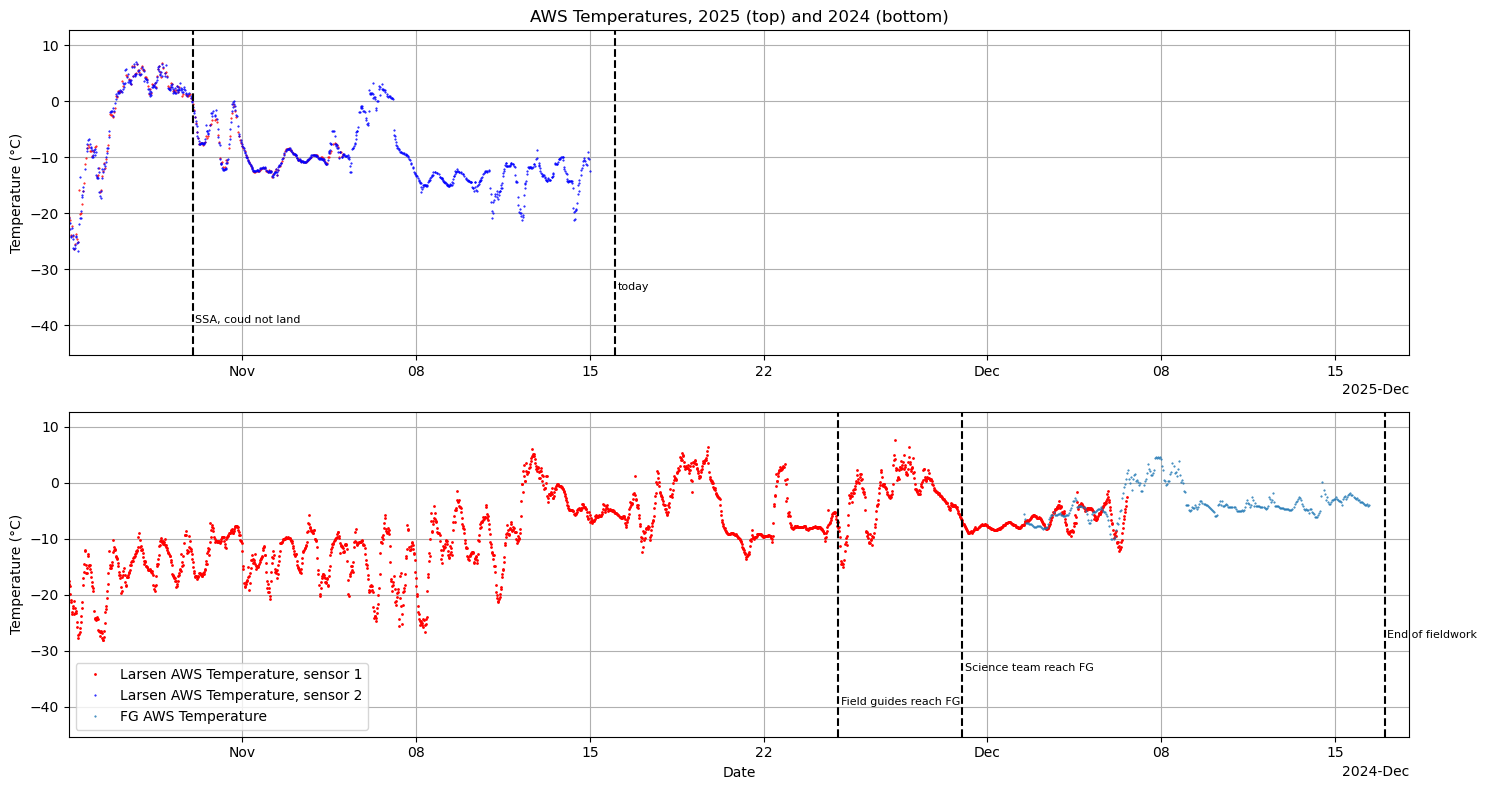

In [490]:
fig, ax = plt.subplots(2, figsize=(15, 8))

def add_times(date, y_pos, label, ax):
    ax.axvline(pd.Timestamp(date), color="k", linestyle="--")
    ax.text(pd.Timestamp(date)+pd.Timedelta(days=0.1), y_pos,label, ha="left", va="bottom", fontsize=8)

year = 2025
aws20_ds1.plot(ax = ax[0], xlim = (pd.Timestamp(f'{year}-10-25'), pd.Timestamp(f'{year}-12-18')), linestyle=' ', marker='.', c = 'r', markersize = 1, label='Larsen AWS Temperature, sensor 1')
aws20_ds2.plot(ax = ax[0], xlim = (pd.Timestamp(f'{year}-10-25'), pd.Timestamp(f'{year}-12-18')),  linestyle=' ', marker='.', c = 'b', markersize = 1, label='Larsen AWS Temperature, sensor 2')
ax[0].set_ylabel('Temperature (°C)')
ax[0].set_xlabel('')
ax[0].set_title(f'AWS Temperatures, 2025 (top) and 2024 (bottom)')
ax[0].grid()
add_times('2025-11-16', -34, 'today', ax[0])
add_times('2025-10-30', -40, 'SSA, coud not land', ax[0])

year = 2024
aws20_ds1.plot(ax = ax[1], xlim = (pd.Timestamp(f'{year}-10-25'), pd.Timestamp(f'{year}-12-18')),  linestyle=' ', marker='o', c = 'r', markersize = 1, label='Larsen AWS Temperature, sensor 1')
aws20_ds2.plot(ax = ax[1], xlim = (pd.Timestamp(f'{year}-10-25'), pd.Timestamp(f'{year}-12-18')),  linestyle=' ', marker='.', c = 'b', markersize = 1, label='Larsen AWS Temperature, sensor 2')
FG_AWS.TempVue20T_C_Avg.plot(ax = ax[1], linestyle=' ', marker='.',label ='FG AWS Temperature', markersize = 1)

ax[1].set_ylabel('Temperature (°C)')
ax[1].set_xlabel('Date')
# ax[1].set_title(f'AWS Temperature records, {year}')
ax[1].grid()



add_times('2024-11-25', -40, 'Field guides reach FG', ax[1])
add_times('2024-11-30', -34, 'Science team reach FG', ax[1])
add_times('2024-12-17', -28, 'End of fieldwork', ax[1]  )
plt.tight_layout()
plt.legend(loc='lower left')

In [465]:
year

2024

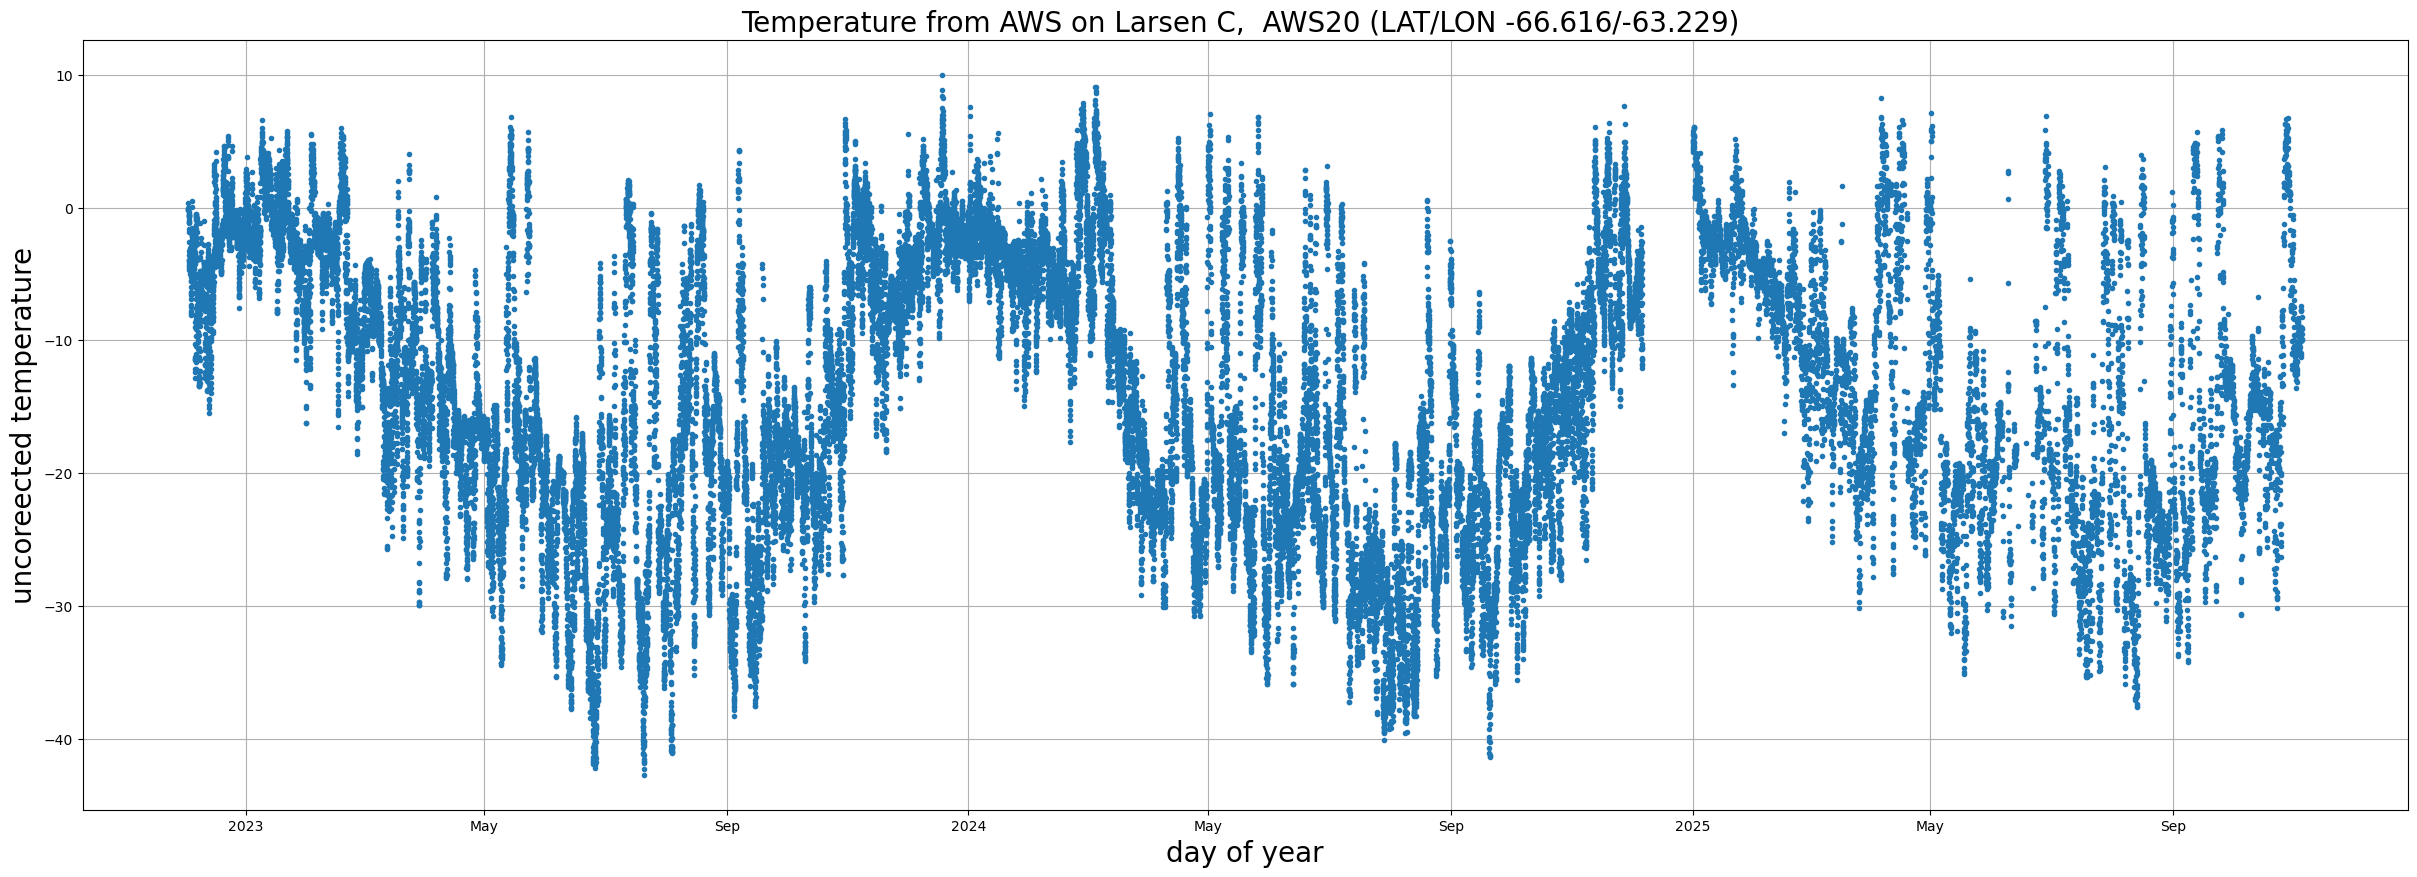

In [ ]:
aws20_ds1.t.plot(figsize=(30, 10), marker = '.', linestyle = '')
plt.xlabel('day of year', fontsize = 20)
plt.ylabel('uncoreected temperature', fontsize = 20)
plt.title('Temperature from AWS on Larsen C,  AWS20 (LAT/LON -66.616/-63.229) ', fontsize = 20)
plt.grid()

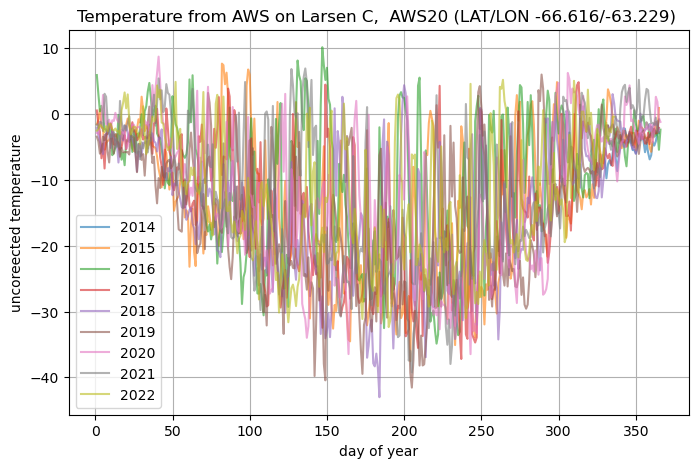

In [612]:
grouped = aws18_ds.groupby("datetime.year")
aws18_ds = aws18_ds.assign_coords(dayofyear=aws18_ds['datetime'].dt.dayofyear)

# Plot each year on top of each other
plt.figure(figsize=(8, 5))
for year, subset in grouped:
    # if year in [2024, 2025]:
    subset.groupby('datetime.dayofyear').mean().plot(label=str(year), alpha=0.6)

plt.legend()
plt.xlabel('day of year')
plt.ylabel('uncoreected temperature')
plt.title('Temperature from AWS on Larsen C,  AWS20 (LAT/LON -66.616/-63.229) ')
plt.grid()

In [611]:
aws18_ds

<xarray.DataArray 'temperature' (datetime: 70269)> Size: 562kB
array([-5.8642, -6.204 , -6.308 , ...,  1.1366,  3.2536,  1.3908],
      shape=(70269,))
Coordinates:
  * datetime   (datetime) datetime64[ns] 562kB 2014-11-25T18:00:00 ... 2022-1...
    dayofyear  (datetime) int64 562kB 329 329 329 329 329 ... 336 336 336 336

In [7]:
tskin = xr.open_dataset('/Users/jkingslake/Documents/data/racmo_ap_daily/tskin.zarr', chunks={})


In [19]:
import geopandas as gpd

## AWS location

In [553]:
geometry = gpd.points_from_xy([-63.229], [-66.616])
aws20_locations = gpd.GeoDataFrame(geometry=geometry, crs="EPSG:4326")
# save to file
aws20_locations.to_file("../../data/flask/aws/larsen_AWS20_location.geojson", driver="GeoJSON")

In [554]:
geometry = gpd.points_from_xy([aws18_df['Longitude'].mean()], [aws18_df['Latitude'].mean()])
aws18_locations = gpd.GeoDataFrame(geometry=geometry, crs="EPSG:4326")
# save to file
aws18_locations.to_file("../../data/flask/aws/larsen_AWS18_location.geojson", driver="GeoJSON")

## Field site locations


In [565]:
field_site_locations = gpd.read_file("/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/fieldwork/recce_planning_oct25/site_names.shp")
field_site_locations.to_crs(epsg=4326, inplace=True)
field_site_locations

,Site,Lat,Long,Elevation,geometry
0,Camp,-65.811924,-62.714833,450,POINT (-62.71483 -65.81192)
1,Rock site,-65.801193,-62.672086,444,POINT (-62.67209 -65.80119)
2,Site 1,-65.793503,-62.677287,381,POINT (-62.67729 -65.7935)
3,Site 2,-65.783112,-62.692062,395,POINT (-62.69206 -65.78311)
4,Site 3,-65.784583,-62.663775,395,POINT (-62.66378 -65.78458)
5,Site 4,-65.775563,-62.667177,395,POINT (-62.66718 -65.77556)


In [566]:
from pyproj import Transformer

# WGS84 (lon, lat)  ->  RACMO rotated coords (rlon, rlat)
to_rot = Transformer.from_crs(
    "EPSG:4326",
    "+proj=ob_tran +o_proj=longlat +o_lat_p=-180 +lon_0=30 +datum=WGS84 +no_defs",
    always_xy=True
)

# RACMO rotated coords (rlon, rlat) -> WGS84 (lon, lat)
to_geo = Transformer.from_crs(
    "+proj=ob_tran +o_proj=longlat +o_lat_p=-180 +lon_0=30 +datum=WGS84 +no_defs",
    "EPSG:4326",
    always_xy=True
)
# # example
# lon, lat = -45.0, -75.0
# rlon, rlat = to_rot.transform(lon, lat)
# lon2, lat2 = to_geo.transform(rlon, rlat)

In [567]:
aws20_locations

,geometry
0,POINT (-63.229 -66.616)


In [568]:
rlon_AWS18, rlat_AWS18 = to_rot.transform(aws18_locations.geometry.x.item(), aws18_locations.geometry.y.item())
rlon_AWS20, rlat_AWS20 = to_rot.transform(aws20_locations.geometry.x.item(), aws20_locations.geometry.y.item())
rlon_field_site, rlat_field_site = to_rot.transform(field_site_locations.geometry.x.values, field_site_locations.geometry.y.values)
rlon_field_site, rlat_field_site

(array([-24.16403636, -24.17551069, -24.18310401, -24.19322915,
        -24.19225313, -24.20120745]),
 array([-1.11201084, -1.0949685 , -1.09742602, -1.10392385, -1.09226905,
        -1.09404591]))

In [578]:
def zoom_in(x, y, d):
    plt.xlim(x - d, x + d)
    plt.ylim(y - d, y + d)

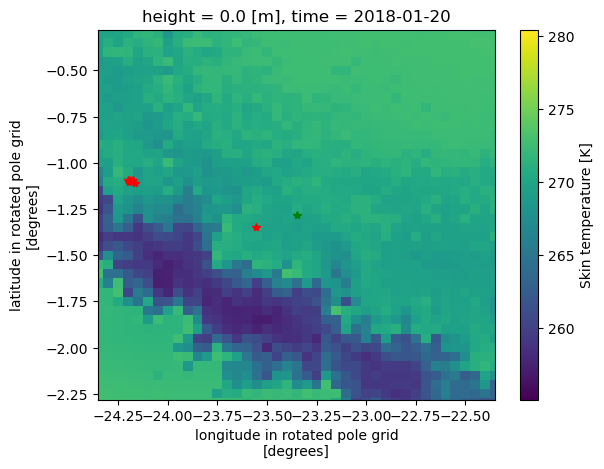

In [585]:
d = 10
tskin.tskin.sel(rlon = slice(rlon_field_site[0]-d, rlon_field_site[0]+d), rlat = slice(rlat_field_site[0]-d, rlat_field_site[0]+d))\
    .sel(time='2018-01-20', method='nearest').plot()
    
plt.plot(rlon_AWS18, rlat_AWS18,'r*')
plt.plot(rlon_AWS20, rlat_AWS20,'g*')

plt.plot(rlon_field_site, rlat_field_site,'r*')
# plt.xlim(rlon_AWS-1.5, rlon_AWS+0.5)
# plt.ylim(rlat_AWS-1, rlat_AWS+1)
zoom_in(rlon_AWS20, rlat_AWS20, 1)
# plt.gca().set_aspect('equal')

In [3]:
fig, ax = plt.subplots(figsize=(30, 10))

aws18_tskin = tskin.tskin.sel(method='nearest', rlon=rlon_AWS18, rlat=rlat_AWS18)-273
aws18_ds.plot(ax=ax, label='data from AWS18')
aws18_tskin.plot(ax=ax, xlim=(pd.Timestamp('2016-01-01'), pd.Timestamp('2019-12-31')),  label='RACMO at AWS18')
ax.legend()


NameError: name 'plt' is not defined

In [4]:
plt.plot(aws18_tskin.values, aws18_ds.values, '.', alpha=0.1)
plt.xlabel('RACMO Tskin (°C)')
plt.ylabel('AWS18 Temperature (°C)')

NameError: name 'plt' is not defined

In [5]:
fig, ax = plt.subplots(figsize=(30, 10))

tskin.tskin.sel( method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)\
    .plot(xlim=(pd.Timestamp('2016-01-01'), pd.Timestamp('2019-12-31')),  ax=ax, label='AWS20 Larsen C')
I = 5
tskin.tskin.sel(method='nearest', rlon=rlon_field_site[I], rlat=rlat_field_site[I])\
    .plot( xlim=(pd.Timestamp('2016-01-01'), pd.Timestamp('2019-12-31')),  ax=ax, label=field_site_locations.Site.values[I])

I = 0
tskin.tskin.sel(method='nearest', rlon=rlon_field_site[I], rlat=rlat_field_site[I])\
    .plot( xlim=(pd.Timestamp('2016-01-01'), pd.Timestamp('2019-12-31')),  ax=ax, label=field_site_locations.Site.values[I])

plt.grid()
plt.legend()


NameError: name 'plt' is not defined

Text(0, 0.5, 'Camp Tskin (K)')

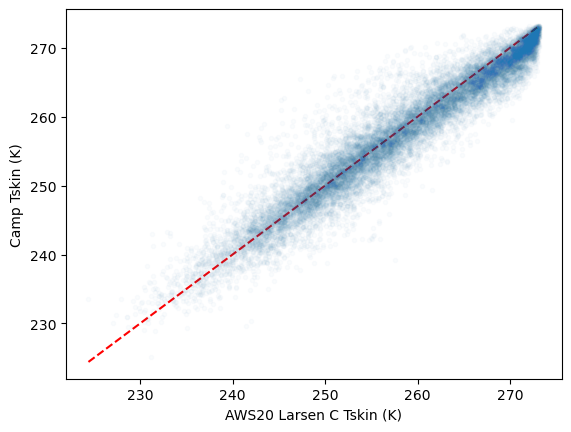

In [ ]:
x = tskin.tskin.sel( method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)
y = tskin.tskin.sel( method='nearest', rlon=rlon_field_site[5], rlat=rlat_field_site[5])

plt.plot([x.min(), x.max()], [x.min(), x.max()], 'r--')
plt.plot(x, y, '.', alpha=0.02)
plt.xlabel('AWS20 Larsen C Tskin (K)')
plt.ylabel(f'{field_site_locations.Site.values[I]} Tskin (K)')
## add 1:1 line


Text(0.5, 1.0, 'Tskin comparison during Oct-Nov')

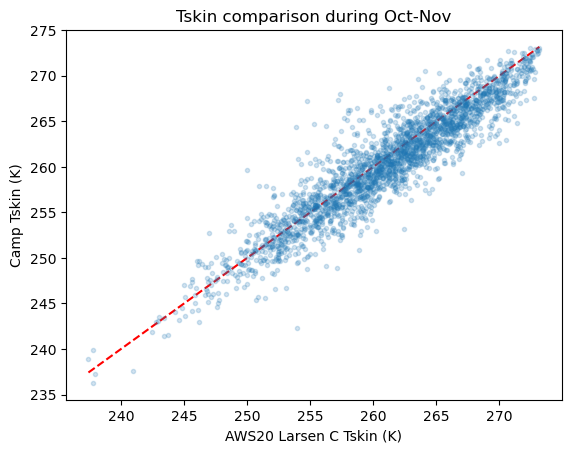

In [ ]:
tskin_ON = tskin.tskin.where(tskin.tskin.time.dt.month.isin([10, 11]), drop=True)



x = tskin_ON.sel( method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)
y = tskin_ON.sel( method='nearest', rlon=rlon_field_site[5], rlat=rlat_field_site[5])

plt.plot([x.min(), x.max()], [x.min(), x.max()], 'r--')
plt.plot(x, y, '.', alpha=0.2)
plt.xlabel('AWS20 Larsen C Tskin (K)')
plt.ylabel(f'{field_site_locations.Site.values[I]} Tskin (K)')
plt.title('Tskin comparison during Oct-Nov')


Text(0.5, 1.0, 'Mean RACMO Tskin during Oct-Nov')

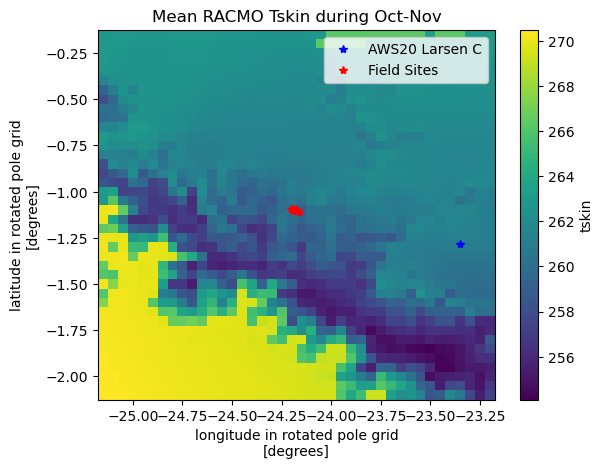

In [ ]:

d=1
tskin_ON_mean = tskin_ON.mean(dim='time')
tskin_ON_mean.sel(rlon = slice(rlon_field_site[0]-d, rlon_field_site[0]+d), rlat = slice(rlat_field_site[0]-d, rlat_field_site[0]+d)).plot()
plt.plot(rlon_AWS20, rlat_AWS20,'b*', label='AWS20 Larsen C')
plt.plot(rlon_field_site, rlat_field_site,'r*', label='Field Sites')
plt.legend()
plt.title('Mean RACMO Tskin during Oct-Nov')

tskin_ON_mean


In [231]:
import statsmodels.formula.api as smf

df = pd.DataFrame({"x": x.squeeze().values, "y": y.squeeze().values})
df

,x,y
0,266.198639,265.085358
1,268.123871,267.850433
2,269.351929,268.867554
3,273.114563,273.075500
4,272.949097,272.300659
...,...,...
14848,253.420059,256.060669
14849,257.937988,258.133301
14850,259.160828,258.481140
14851,253.920044,255.755981


In [232]:
model = smf.ols("y ~ x", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                 1.630e+05
Date:                Thu, 13 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:20:38   Log-Likelihood:                -35928.
No. Observations:               14853   AIC:                         7.186e+04
Df Residuals:                   14851   BIC:                         7.187e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.5578      0.580     40.619      0.0

In [ ]:
AWS_t = tskin.tskin.sel(method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)
corr=xr.corr(AWS_t, tskin.tskin, dim='time').load()

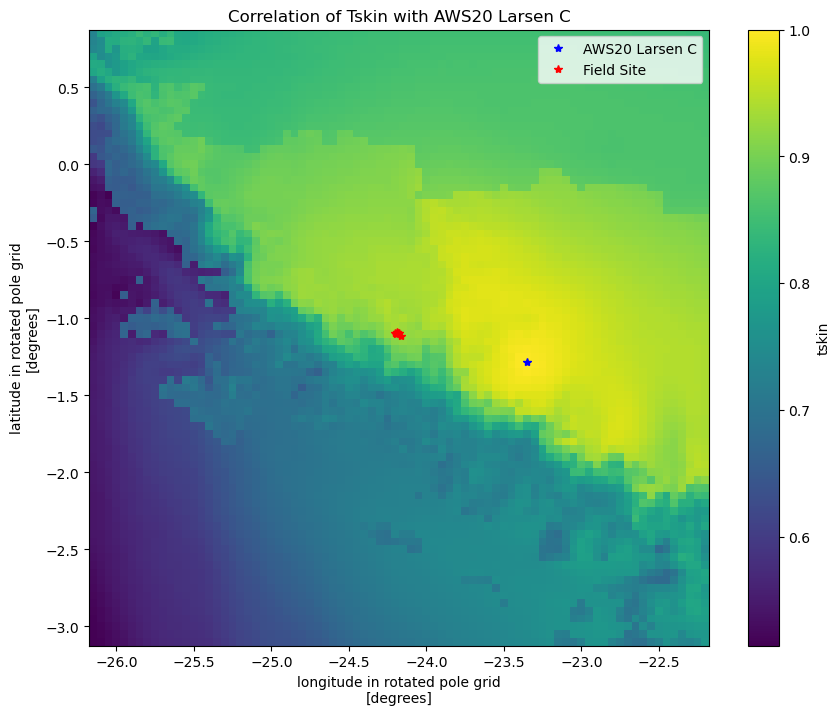

In [ ]:
d = 2
corr.sel(rlon = slice(rlon_field_site[0]-d, rlon_field_site[0]+d), rlat = slice(rlat_field_site[0]-d, rlat_field_site[0]+d)).plot(figsize=(10, 8))
plt.title('Correlation of Tskin with AWS20 Larsen C')
plt.plot(rlon_AWS20, rlat_AWS20,'b*', label='AWS20 Larsen C')
plt.plot(rlon_field_site, rlat_field_site,'r*', label='Field Site')
plt.legend()


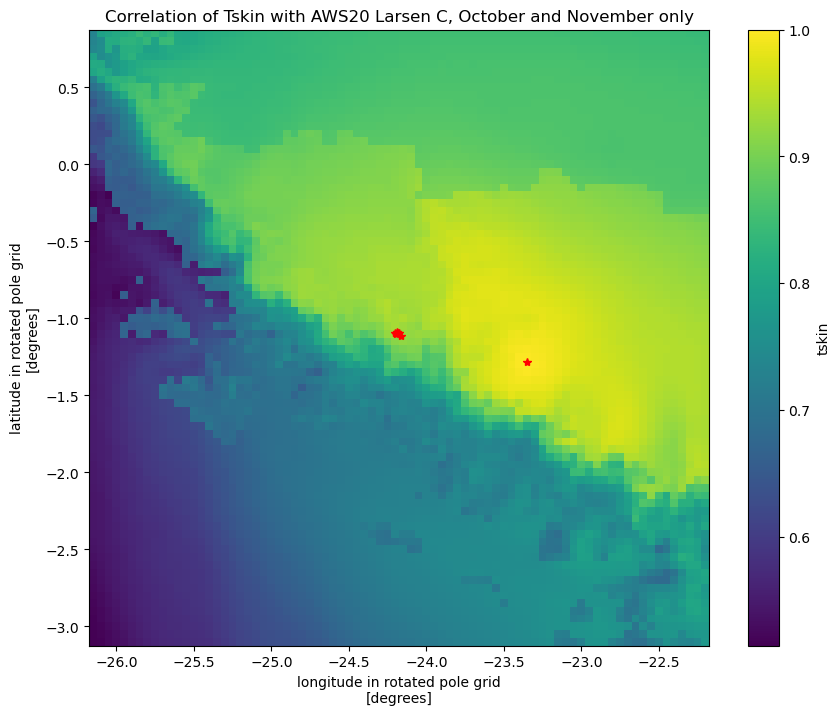

In [ ]:
tskin_ON = tskin.tskin.where(tskin.tskin.time.dt.month.isin([10, 11]), drop=True)
AWS_t_ON = tskin_ON.sel(method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)
corr=xr.corr(AWS_t_ON, tskin_ON, dim='time').load()

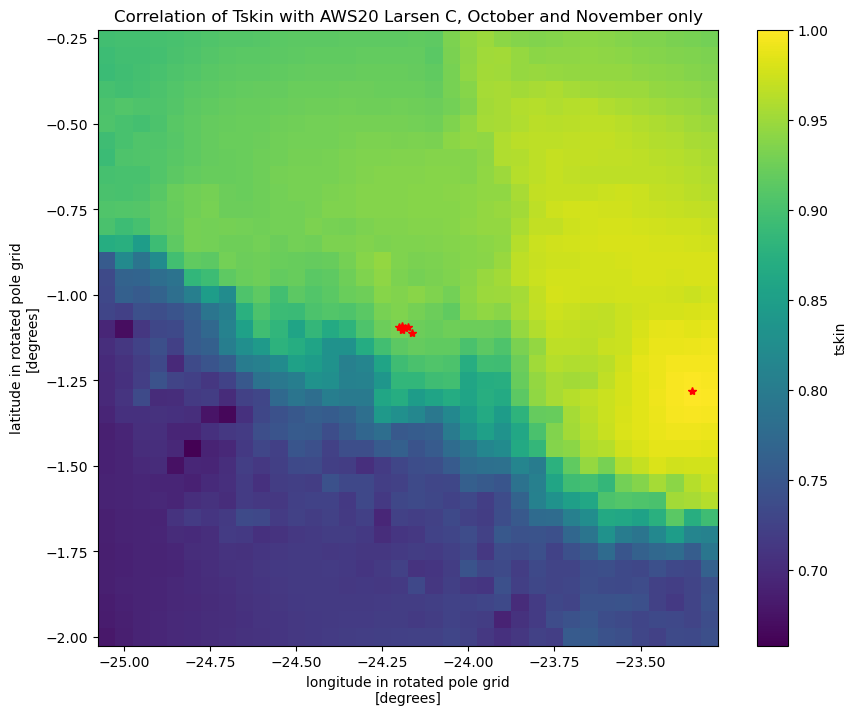

In [ ]:
d = 0.9
corr.sel(rlon = slice(rlon_field_site[0]-d, rlon_field_site[0]+d), rlat = slice(rlat_field_site[0]-d, rlat_field_site[0]+d)).plot(figsize=(10, 8))
plt.title('Correlation of Tskin with AWS20 Larsen C, October and November only')
plt.plot(rlon_AWS20, rlat_AWS20,'r*')
plt.plot(rlon_field_site, rlat_field_site,'r*')

In [262]:
def corr_with_AWS(fld_chunk):
    # fld_chunk is one year's worth of data
    aws_chunk = AWS_t.sel(time=fld_chunk.time)   # align to same times
    return xr.corr(aws_chunk, fld_chunk, dim="time")

corr_yearly = tskin.tskin.groupby("time.year").map(corr_with_AWS).load()

In [273]:
corr_yearly#.hvplot.image(x="rlon", y="rlat")

<xarray.DataArray 'tskin' (year: 41, height: 1, rlat: 294, rlon: 390)> Size: 19MB
array([[[[0.62194943, 0.6236972 , 0.62566143, ..., 0.6325134 ,
          0.631352  , 0.63104177],
         [0.6208986 , 0.62275535, 0.6247725 , ..., 0.6338176 ,
          0.6324102 , 0.6319836 ],
         [0.6202047 , 0.62219584, 0.62368995, ..., 0.63427114,
          0.6338344 , 0.6319072 ],
         ...,
         [0.53837657, 0.5405157 , 0.54235214, ..., 0.7517018 ,
          0.75189984, 0.7516438 ],
         [0.5377648 , 0.53998065, 0.5417943 , ..., 0.7516861 ,
          0.7514426 , 0.7509436 ],
         [0.53734815, 0.53934246, 0.5410702 , ..., 0.75087494,
          0.7510273 , 0.7505685 ]]],


       [[[0.51888406, 0.52149826, 0.5231536 , ..., 0.6343635 ,
          0.6370079 , 0.6323058 ],
         [0.5172551 , 0.5194961 , 0.5211531 , ..., 0.6416331 ,
          0.6393242 , 0.6360012 ],
         [0.5150796 , 0.5170058 , 0.51916677, ..., 0.6406855 ,
...
         [0.407246  , 0.41048494, 0.41378984, ..., 0.66009974,
          0.66037834, 0.6613723 ],
         [0.40839416, 0.41184244, 0.41509822, ..., 0.6594926 ,
          0.66021055, 0.6613189 ]]],


       [[[0.66353494, 0.6631934 , 0.6640422 , ..., 0.4148413 ,
          0.42017907, 0.41166493],
         [0.6665836 , 0.66759664, 0.6672286 , ..., 0.42380524,
          0.4225659 , 0.41856626],
         [0.6705943 , 0.67150337, 0.6718977 , ..., 0.42172977,
          0.4121725 , 0.413875  ],
         ...,
         [0.69995177, 0.7001221 , 0.7005124 , ..., 0.7070702 ,
          0.7088555 , 0.7102732 ],
         [0.7002038 , 0.7005703 , 0.70097643, ..., 0.70868134,
          0.70967305, 0.71079385],
         [0.70077837, 0.701042  , 0.7014856 , ..., 0.7090221 ,
          0.7108617 , 0.71204925]]]],
      shape=(41, 1, 294, 390), dtype=float32)
Coordinates:
  * height   (height) float64 8B 0.0
  * rlat     (rlat) float64 2kB -8.7 -8.65 -8.6 -8.55 -8.5 ... 5.8 5.85 5.9 5.95
  * rlon     (rlon) float64 3kB -32.0 -31.95 -31.9 ... -12.65 -12.6 -12.55
  * year     (year) int64 328B 1979 1980 1981 1982 1983 ... 2016 2017 2018 2019

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

@widgets.interact(idx=(0, corr_yearly.year.size - 1))
def plot_frame(idx=0):
    plt.figure(figsize=(6,5))
    corr_yearly.isel(year=idx).plot(vmin=0, vmax=1  )
    plt.title(str(corr_yearly.year.values[idx]))
    plt.plot(rlon_AWS20, rlat_AWS20,'r*')
    plt.plot(rlon_field_site, rlat_field_site,'r*')
    plt.show()

interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

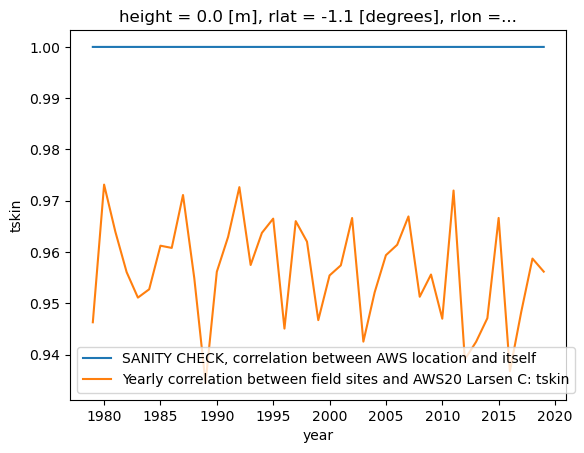

In [ ]:
corr_yearly.sel( method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20).plot(label='SANITY CHECK, correlation between AWS location and itself')
corr_yearly.sel( method='nearest', rlon=rlon_field_site[5], rlat=rlat_field_site[5]).plot(label='Yearly correlation between field sites and AWS20 Larsen C: tskin')
plt.legend()

In [ ]:
d=0.5
AWS_t = tskin.tskin.sel(method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)
field = tskin.tskin.sel(rlon = slice(rlon_field_site[0]-d, rlon_field_site[0]+d), rlat = slice(rlat_field_site[0]-d, rlat_field_site[0]+d))

W = 365  # example: 365-day window; use whatever makes sense (e.g. 30, 90, etc.)

aws_roll = (
    AWS_t
    .rolling(time=W, center=True, min_periods=W)
    .construct("window")
)

field_roll = (
    field
    .rolling(time=W, center=True, min_periods=W)
    .construct("window")
)

# Rolling correlation: correlate over "window"
corr_roll = xr.corr(aws_roll, field_roll, dim="window").compute()
corr_roll

<xarray.DataArray 'tskin' (time: 14853, height: 1, rlat: 20, rlon: 20)> Size: 24MB
array([[[[0.853149  , 0.8556717 , 0.83443224, ..., 0.83631545,
          0.85647786, 0.86154425],
         [0.85552585, 0.85917526, 0.8539276 , ..., 0.8348366 ,
          0.8711006 , 0.9056338 ],
         [0.8634856 , 0.86500967, 0.83892554, ..., 0.8343127 ,
          0.8946014 , 0.9303834 ],
         ...,
         [0.96340615, 0.9622999 , 0.9651466 , ..., 0.9835297 ,
          0.98713756, 0.9875539 ],
         [0.95932424, 0.95841146, 0.95869774, ..., 0.98413867,
          0.98531914, 0.9857079 ],
         [0.9569251 , 0.9560302 , 0.9570203 , ..., 0.98068863,
          0.9866254 , 0.9843342 ]]],


       [[[0.8501762 , 0.8525593 , 0.83093804, ..., 0.8331995 ,
          0.85280955, 0.85794806],
         [0.8526154 , 0.8560542 , 0.85046124, ..., 0.8317857 ,
          0.8674782 , 0.90283674],
         [0.86073667, 0.86190575, 0.83550847, ..., 0.83133876,
...
         [0.9126268 , 0.9136177 , 0.9170273 , ..., 0.9748025 ,
          0.97459155, 0.9626633 ],
         [0.91175455, 0.91337055, 0.9177316 , ..., 0.96909845,
          0.9747948 , 0.9659787 ]]],


       [[[0.7149198 , 0.6686485 , 0.73090786, ..., 0.810641  ,
          0.821361  , 0.8199274 ],
         [0.71146625, 0.653621  , 0.72453535, ..., 0.78801864,
          0.8087729 , 0.86569715],
         [0.7064032 , 0.6734626 , 0.7350333 , ..., 0.79660577,
          0.83243096, 0.8829111 ],
         ...,
         [0.9135668 , 0.912981  , 0.9182382 , ..., 0.9724736 ,
          0.98132855, 0.98030293],
         [0.9135383 , 0.91439605, 0.9176506 , ..., 0.9745426 ,
          0.9743385 , 0.9627354 ],
         [0.91236085, 0.9138696 , 0.91810197, ..., 0.9687926 ,
          0.97461516, 0.9662326 ]]]],
      shape=(14853, 1, 20, 20), dtype=float32)
Coordinates:
  * height   (height) float64 8B 0.0
  * rlat     (rlat) float64 160B -1.6 -1.55 -1.5 -1.45 ... -0.8 -0.75 -0.7 -0.65
  * rlon     (rlon) float64 160B -24.65 -24.6 -24.55 ... -23.8 -23.75 -23.7
  * time     (time) datetime64[ns] 119kB 1979-01-01 1979-01-02 ... 2019-08-31

In [8]:
@widgets.interact(idx=(0, corr_roll.time.size - 1))
def plot_frame(idx=0):
    plt.figure(figsize=(6,5))
    corr_roll.isel(time=idx).plot(vmin=0, vmax=1  )
    plt.title(str(corr_roll.time.values[idx]))
    plt.plot(rlon_AWS20, rlat_AWS20,'r*')
    plt.plot(rlon_field_site, rlat_field_site,'r*')
    plt.show()


# corr_roll.isel(time=1000).plot()
# plt.plot(rlon_AWS, rlat_AWS,'r*')
# plt.plot(rlon_field_site, rlat_field_site,'r*')

NameError: name 'widgets' is not defined

Text(0.5, 1.0, 'correlation at field site computed over a 1-year rolling window')

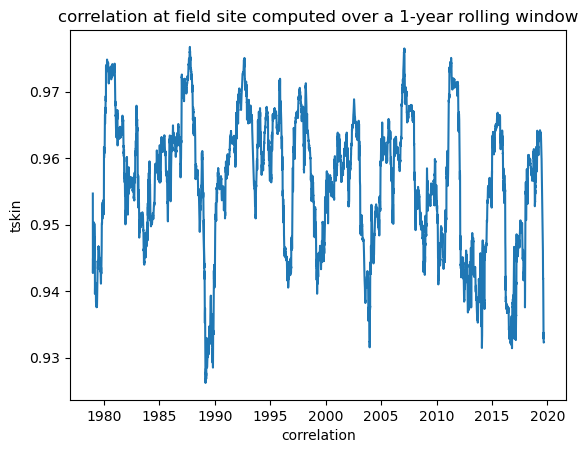

In [374]:
corr_roll.sel( method='nearest', rlon=rlon_field_site[5], rlat=rlat_field_site[5]).plot(label='Yearly correlation between field sites and AWS20 Larsen C: tskin')
plt.xlabel('correlation')
plt.title('correlation at field site computed over a 1-year rolling window')

In [ ]:
from dask.distributed import Client, LocalCluster

cluster = LocalCluster(
    n_workers=4,        # number of workers
    threads_per_worker=1,
    memory_limit="4GB", # per worker
)
client = Client(cluster)
client

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52968 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:52968/status,
Dashboard: http://127.0.0.1:52968/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:52969,Workers: 0
Dashboard: http://127.0.0.1:52968/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:52980,Total threads: 1
Dashboard: http://127.0.0.1:52981/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:52972,


2025-11-14 18:04:42,442 - tornado.application - ERROR - Exception in callback <bound method SystemMonitor.update of <SystemMonitor: cpu: 13 memory: 140 MB fds: 270>>
Traceback (most recent call last):
  File "/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/tornado/ioloop.py", line 937, in _run
    val = self.callback()
  File "/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/distributed/system_monitor.py", line 168, in update
    net_ioc = psutil.net_io_counters()
  File "/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/psutil/__init__.py", line 2148, in net_io_counters
    rawdict = _psplatform.net_io_counters()
OSError: [Errno 12] Cannot allocate memory
2025-11-18 07:35:14,716 - distributed.scheduler - WARNING - Worker failed to heartbeat for 442s; attempting restart: <WorkerState 'tcp://127.0.0.1:52980', name: 0, status: running, memory: 0, processing: 0>
2025-11-18 07:35:14,743 - dis

## Compare to our AWS on FG

In [375]:
FG_AWS = xr.load_dataset('aws_season_1.nc')

Text(0.5, 1.0, 'Comparison of our Flask-Glacier AWS and Larsen C AWS, Late 2024')

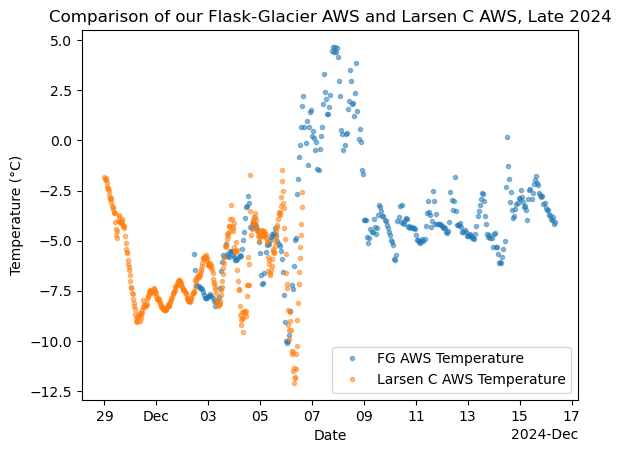

In [ ]:
FG_AWS.TempVue20T_C_Avg.plot( linestyle=' ', marker='.', alpha = 0.5, label ='FG AWS Temperature')
year = 2024
aws20_ds1.t.sel(datetime=slice(pd.Timestamp(f'{year}-11-29'), pd.Timestamp(f'{year}-12-31'))).plot( linestyle=' ', marker='.', alpha = 0.5, label ='Larsen C AWS Temperature')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Comparison of our Flask-Glacier AWS and Larsen C AWS, Late 2024')
# ax[1].set_ylabel('Temperature (°C)')
# ax[1].set_xlabel('Date')

# ax[1].set_title(f'Larsen AWS Temperature, {year}')
# ax[1].grid()


# add_times('2024-11-25', -40, 'Field guides reach FG', ax[1])
# add_times('2024-11-30', -34, 'Science team reach FG', ax[1])
# add_times('2024-12-07', -28, 'End of fieldwork', ax[1]  )